### Notebook 03 – Exploratory Data Analysis

#### Objective

This notebook performs exploratory data analysis on the cleaned metadata generated in Notebook 02.

The objectives are:

- Understand dataset composition
- Explore image characteristics
- Identify class distributions
- Assess image quality
- Detect potential biases
- Generate insights for feature engineering

Input:
- master_metadata.csv

Output:
- EDA figures
- Summary tables
- Research observations

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

from PIL import Image

plt.rcParams["figure.figsize"] = (10,6)

In [2]:
from pathlib import Path

# Project directories
DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")

FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

# Create folders if they don't exist
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
metadata = pd.read_csv("../data/processed/master_metadata.csv")
metadata.head()

,dataset,image_path,file_name,extension,target,valid_image,size_mb,resolution,width,height,aspect_ratio
0,ADMS,../data/raw/adms/Valid/images/c_-308-_jpg.rf.0...,c_-308-_jpg.rf.0b71b13d1c0db0ac91b0997247d22a4...,.jpg,Open Eye,True,0.036607,"(640, 512)",640,512,1.250000
1,ADMS,../data/raw/adms/Valid/images/112_jpg.rf.93fc7...,112_jpg.rf.93fc71b2c98ad78087aaf17c7778f857.jpg,.jpg,Open Eye,True,0.023131,"(640, 480)",640,480,1.333333
2,ADMS,../data/raw/adms/Valid/images/CHANNEL_03_20220...,CHANNEL_03_20220509152715_20220509152725_mp4-8...,.jpg,Open Eye,True,0.018838,"(640, 384)",640,384,1.666667
3,ADMS,../data/raw/adms/Valid/images/358_jpg.rf.0bc5f...,358_jpg.rf.0bc5fd26b9209862fe5336d1cacb2ed8.jpg,.jpg,Open Eye,True,0.031053,"(640, 427)",640,427,1.498829
4,ADMS,../data/raw/adms/Valid/images/_-3-_mp4-96_jpg....,_-3-_mp4-96_jpg.rf.5a65ec89c93eaf85c76b0530bda...,.jpg,NaN,True,0.020555,"(640, 523)",640,523,1.223709


In [4]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 36307 entries, 0 to 36306
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   dataset       36307 non-null  str    
 1   image_path    36307 non-null  str    
 2   file_name     36307 non-null  str    
 3   extension     36307 non-null  str    
 4   target        10889 non-null  str    
 5   valid_image   36307 non-null  bool   
 6   size_mb       36307 non-null  float64
 7   resolution    36307 non-null  str    
 8   width         36307 non-null  int64  
 9   height        36307 non-null  int64  
 10  aspect_ratio  36307 non-null  float64
dtypes: bool(1), float64(2), int64(2), str(6)
memory usage: 2.8 MB


In [5]:
metadata.describe().T

,count,mean,std,min,25%,50%,75%,max
size_mb,36307.0,0.021670,0.007105,0.001648,0.021302,0.022913,0.024247,0.070265
width,36307.0,380.025202,166.498700,60.000000,320.000000,320.000000,640.000000,640.000000
height,36307.0,281.376677,122.047270,60.000000,240.000000,240.000000,360.000000,640.000000
aspect_ratio,36307.0,1.338612,0.228953,0.170313,1.333333,1.333333,1.333333,3.975155


dataset
StateFarm     22423
ADMS           9884
Drowsiness     4000
Name: count, dtype: int64

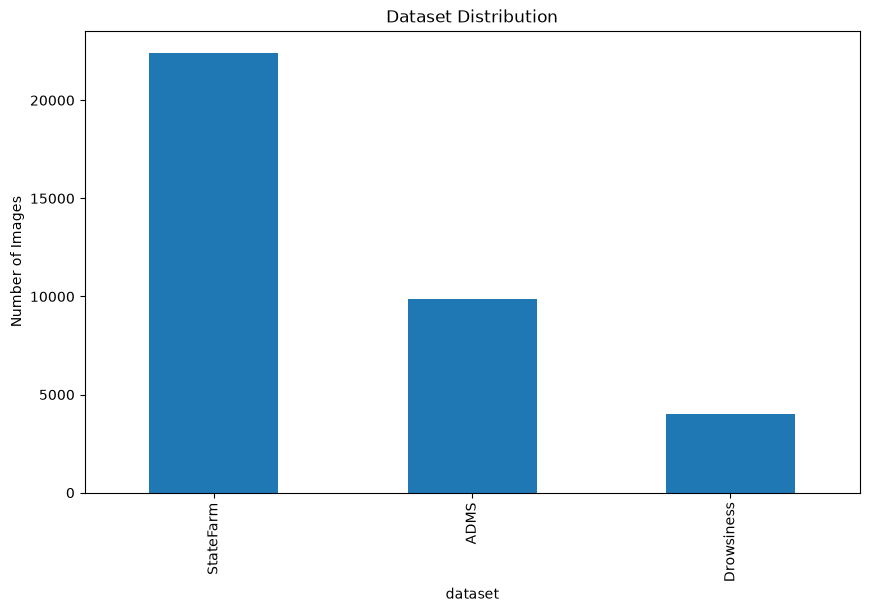

In [6]:
dataset_counts = metadata["dataset"].value_counts()
display(dataset_counts)
dataset_counts.plot(
    kind="bar",
    title="Dataset Distribution"
)
plt.ylabel("Number of Images")
plt.show()

Observation 1: The combined dataset contains 36,307 images from three publicly available Driver Monitoring datasets. StateFarm contributes the largest proportion of images, followed by ADMS and the Drowsiness dataset.

extension
.jpg    32307
.png     4000
Name: count, dtype: int64

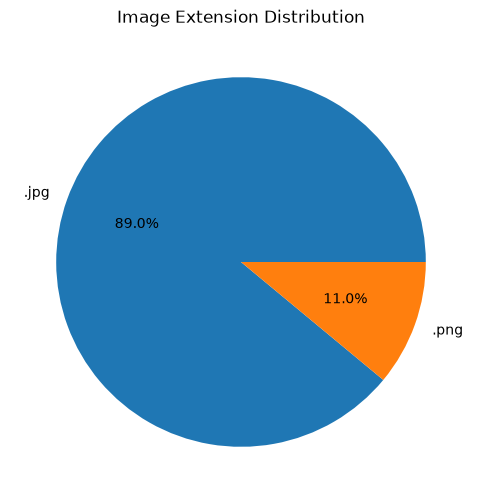

In [7]:
extension_counts = metadata["extension"].value_counts()
display(extension_counts)
extension_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.ylabel("")
plt.title("Image Extension Distribution")
plt.show()

JPEG is the dominant image format, while PNG images are present in a smaller proportion of the dataset. The processing pipeline successfully accommodates multiple image formats without modifying the original data.

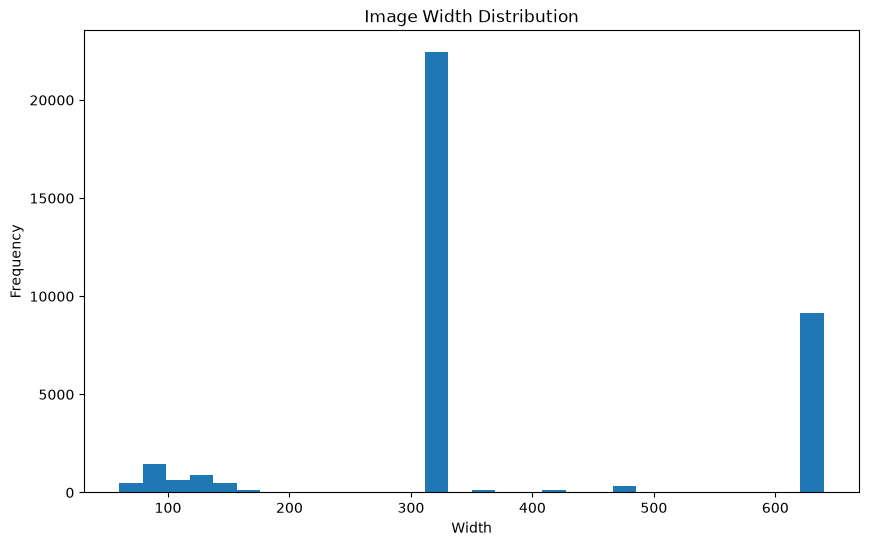

In [8]:
plt.hist(
    metadata["width"],
    bins=30
)
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")
plt.show()

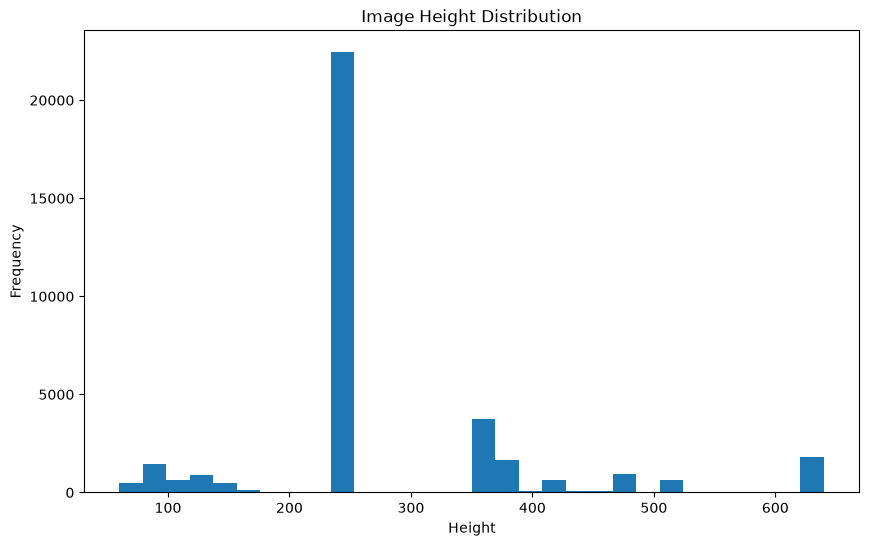

In [9]:
plt.hist(
    metadata["height"],
    bins=30
)
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()

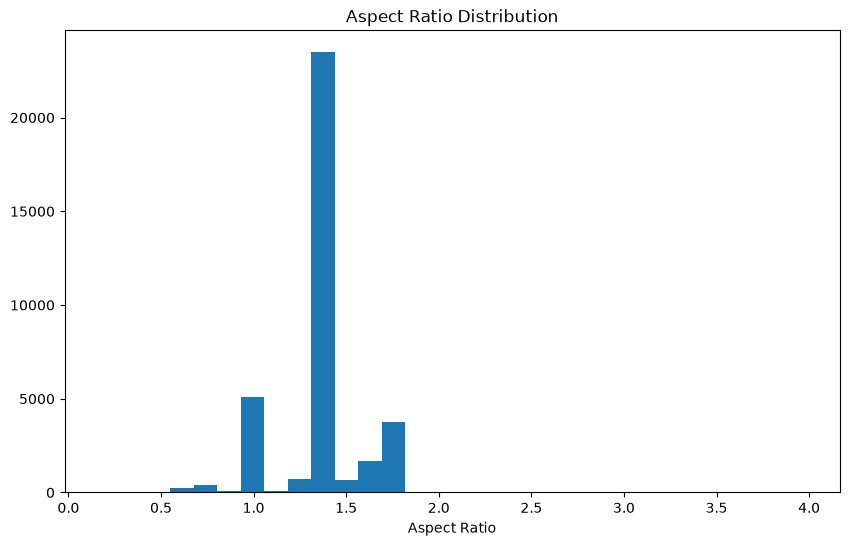

In [10]:
plt.hist(
    metadata["aspect_ratio"],
    bins=30
)
plt.title("Aspect Ratio Distribution")
plt.xlabel("Aspect Ratio")
plt.show()

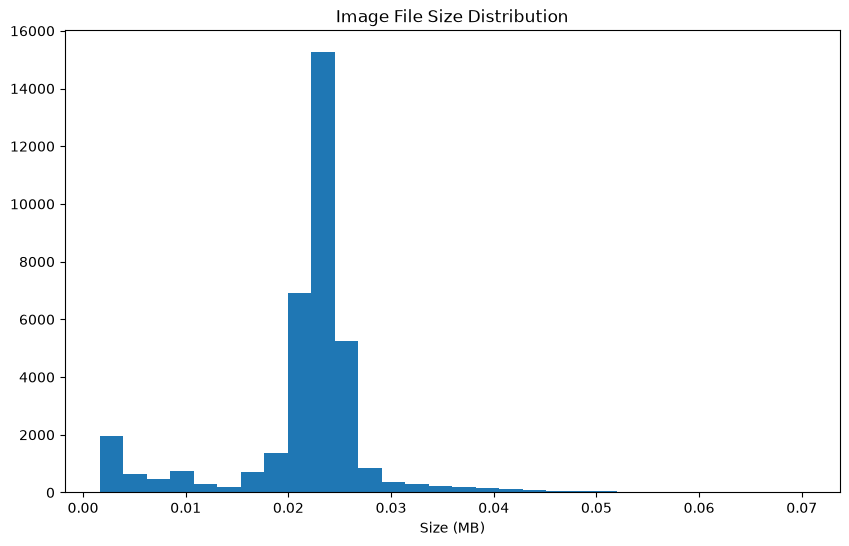

In [11]:
plt.hist(
    metadata["size_mb"],
    bins=30
)
plt.title("Image File Size Distribution")
plt.xlabel("Size (MB)")
plt.show()

In [12]:
plt.savefig(
    "../reports/dataset_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 1000x600 with 0 Axes>

_________________________________________________________________________________________________________________________________________________________________

In [13]:
EDA_SAMPLE_SIZE = 1000
RANDOM_STATE = 42

eda_sample = (
    metadata
    .sample(
        n=min(EDA_SAMPLE_SIZE, len(metadata)),
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)
print(f"EDA Sample Size: {len(eda_sample)}")

EDA Sample Size: 1000


In [14]:
def read_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )
    return img

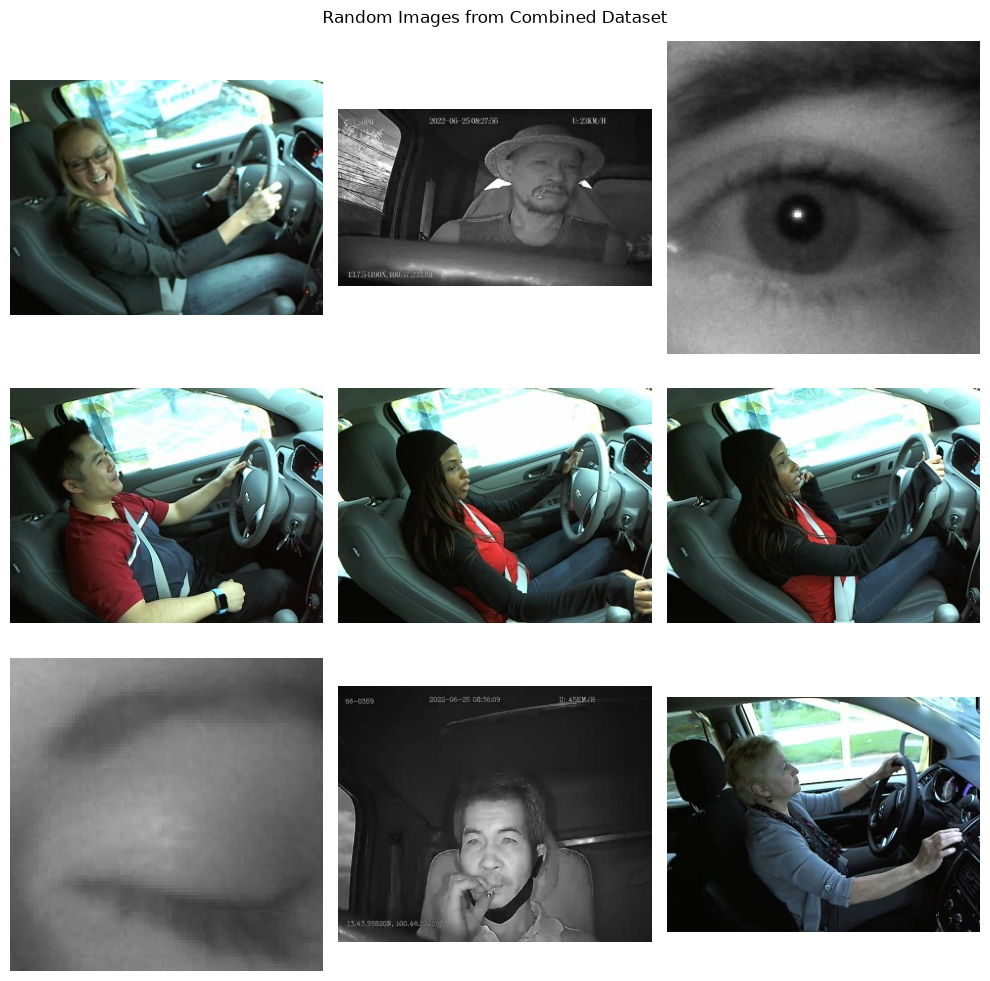

In [15]:
fig, axes = plt.subplots(
    3,
    3,
    figsize=(10,10)
)
for ax in axes.flat:
    img_path = eda_sample.sample(1).iloc[0]["image_path"]
    img = read_image(img_path)
    ax.imshow(img)
    ax.axis("off")
plt.suptitle("Random Images from Combined Dataset")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR/"random_images.png",
    dpi=300
)

In [16]:
def brightness(path):
    img = cv2.imread(path)
    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )
    return gray.mean()

In [17]:
eda_sample["brightness"] = eda_sample["image_path"].apply(
    brightness
)

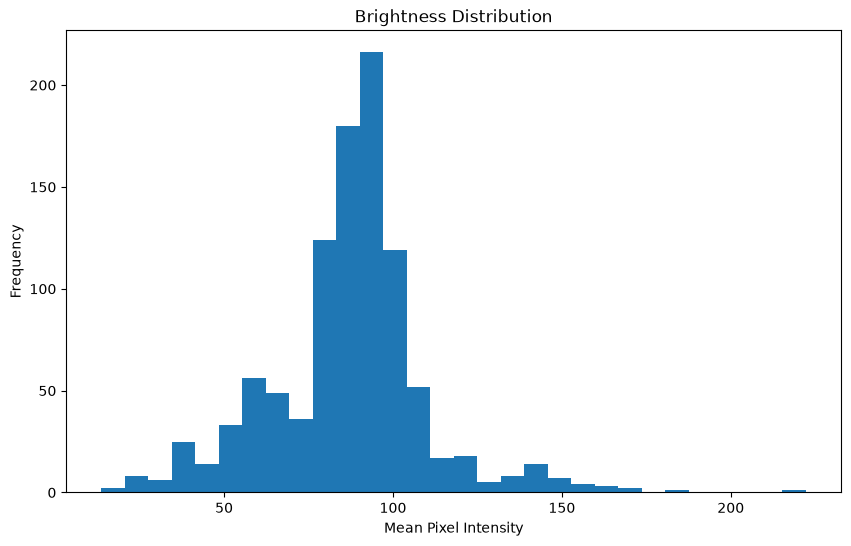

In [18]:
plt.hist(
    eda_sample["brightness"],
    bins=30
)
plt.title("Brightness Distribution")
plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Frequency")
plt.savefig(
    FIGURE_DIR/"brightness_distribution.png",
    dpi=300
)
plt.show()

- Observation: Brightness values exhibit a broad distribution, indicating variability in illumination conditions. This diversity is beneficial for evaluating model robustness under different lighting environments.

In [19]:
def contrast(path):
    img = cv2.imread(path)
    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )
    return gray.std()

In [20]:
eda_sample["contrast"] = eda_sample["image_path"].apply(
    contrast
)

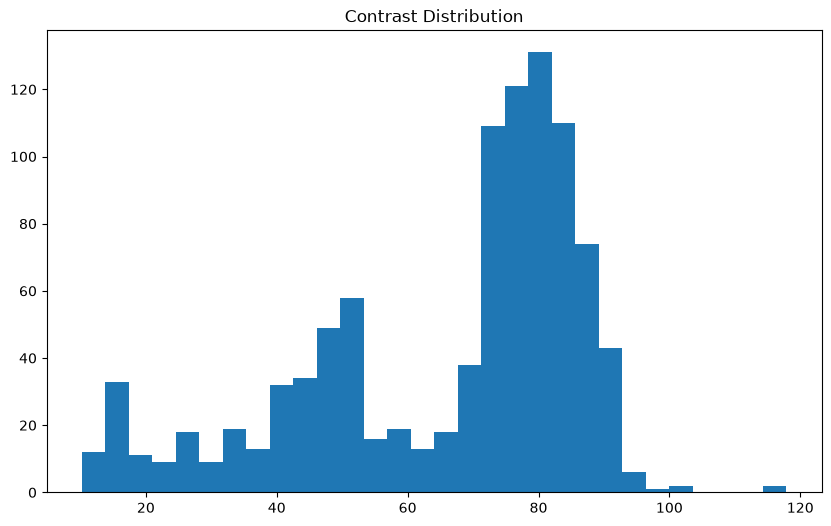

In [21]:
plt.hist(
    eda_sample["contrast"],
    bins=30
)
plt.title("Contrast Distribution")
plt.savefig(
    FIGURE_DIR/"contrast_distribution.png",
    dpi=300
)
plt.show()

In [22]:
def blur_score(path):
    img = cv2.imread(path)
    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )
    return cv2.Laplacian(
        gray,
        cv2.CV_64F
    ).var()

In [23]:
eda_sample["blur_score"] = eda_sample["image_path"].apply(
    blur_score
)

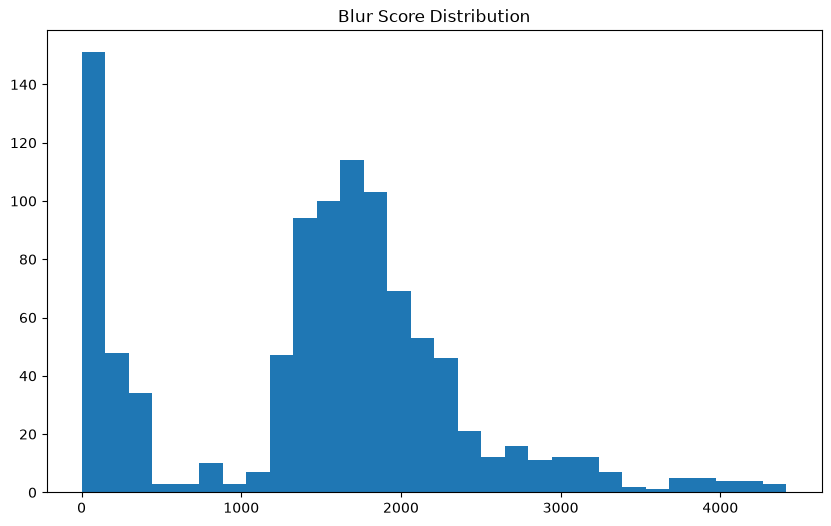

In [24]:
plt.hist(
    eda_sample["blur_score"],
    bins=30
)
plt.title("Blur Score Distribution")
plt.savefig(
    FIGURE_DIR/"blur_distribution.png",
    dpi=300
)
plt.show()

-Observation: mages with lower Laplacian variance correspond to blurrier frames, while higher values indicate sharper images. Understanding blur characteristics helps assess the potential impact of image quality on downstream model performance.

In [25]:
quality_summary = eda_sample[
    [
        "brightness",
        "contrast",
        "blur_score"
    ]
].describe()
display(quality_summary)
quality_summary.to_csv(
    TABLE_DIR/"image_quality_summary.csv"
)

,brightness,contrast,blur_score
count,1000.000000,1000.000000,1000.000000
mean,86.939148,66.176402,1482.613981
std,22.940568,21.299419,919.096462
min,13.676487,10.231968,2.459395
25%,77.456462,50.252998,1007.652367
50%,89.280521,74.368540,1620.368317
75%,97.141432,81.649884,1976.428987
max,222.256659,117.894034,4414.447349


In [ ]:
quality_features = metadata.copy()

quality_features["brightness"] = quality_features["image_path"].apply(brightness)

quality_features["contrast"] = quality_features["image_path"].apply(contrast)

quality_features["blur_score"] = quality_features["image_path"].apply(blur_score)

quality_features[[
    "image_path",
    "brightness",
    "contrast",
    "blur_score"
]].to_csv(
    "../data/processed/image_quality_features.csv",
    index=False
)

,brightness,contrast,blur_score
brightness,1.000000,0.291807,-0.159801
contrast,0.291807,1.000000,0.528747
blur_score,-0.159801,0.528747,1.000000


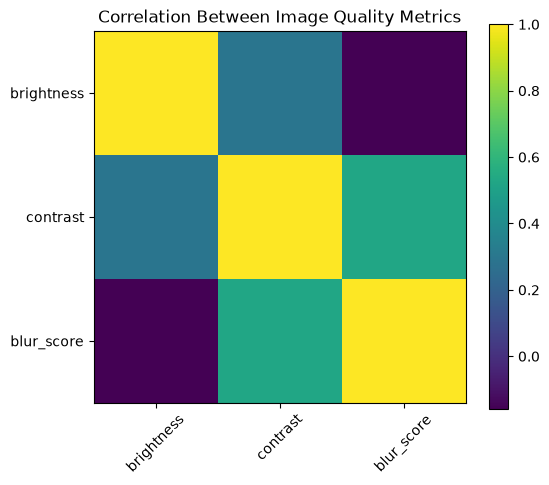

In [ ]:
corr = eda_sample[
    [
        "brightness",
        "contrast",
        "blur_score"
    ]
].corr()
display(corr)
plt.figure(figsize=(6,5))
plt.imshow(corr)
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)
plt.yticks(
    range(len(corr.columns)),
    corr.columns
)
plt.colorbar()
plt.title("Correlation Between Image Quality Metrics")
plt.savefig(
    FIGURE_DIR/"quality_correlation.png",
    dpi=300
)
plt.show()

#### Image Quality Observations

- Observation 1
The sampled images exhibit substantial variation in brightness, reflecting diverse illumination conditions across the integrated datasets.
- Observation 2
Contrast values indicate differences in image clarity and scene composition, which may influence feature extraction and model performance.
- Observation 3
Blur analysis reveals variability in image sharpness. This metric will later be incorporated into the AI Trust Score as an image quality indicator.
- Research Implication
Image quality metrics provide valuable insights into dataset variability and motivate the inclusion of quality-related features during feature engineering.

In [ ]:
def show_dataset_samples(dataset_name, n=6):
    dataset_images = metadata[
        metadata["dataset"] == dataset_name
    ].sample(
        n=n,
        random_state=42
    )
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for ax, (_, row) in zip(axes.flat, dataset_images.iterrows()):
        img = cv2.imread(row["image_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.axis("off")
    plt.suptitle(f"{dataset_name} Sample Images")
    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / f"{dataset_name.lower()}_samples.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

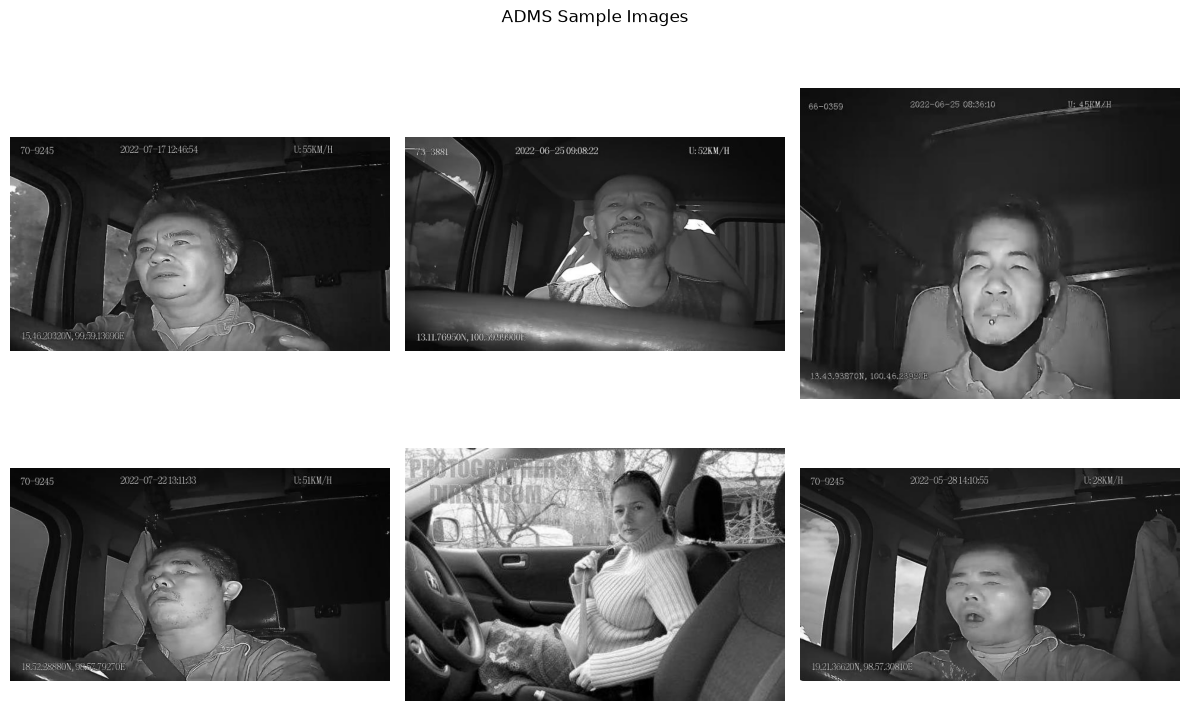

In [ ]:
show_dataset_samples("ADMS")

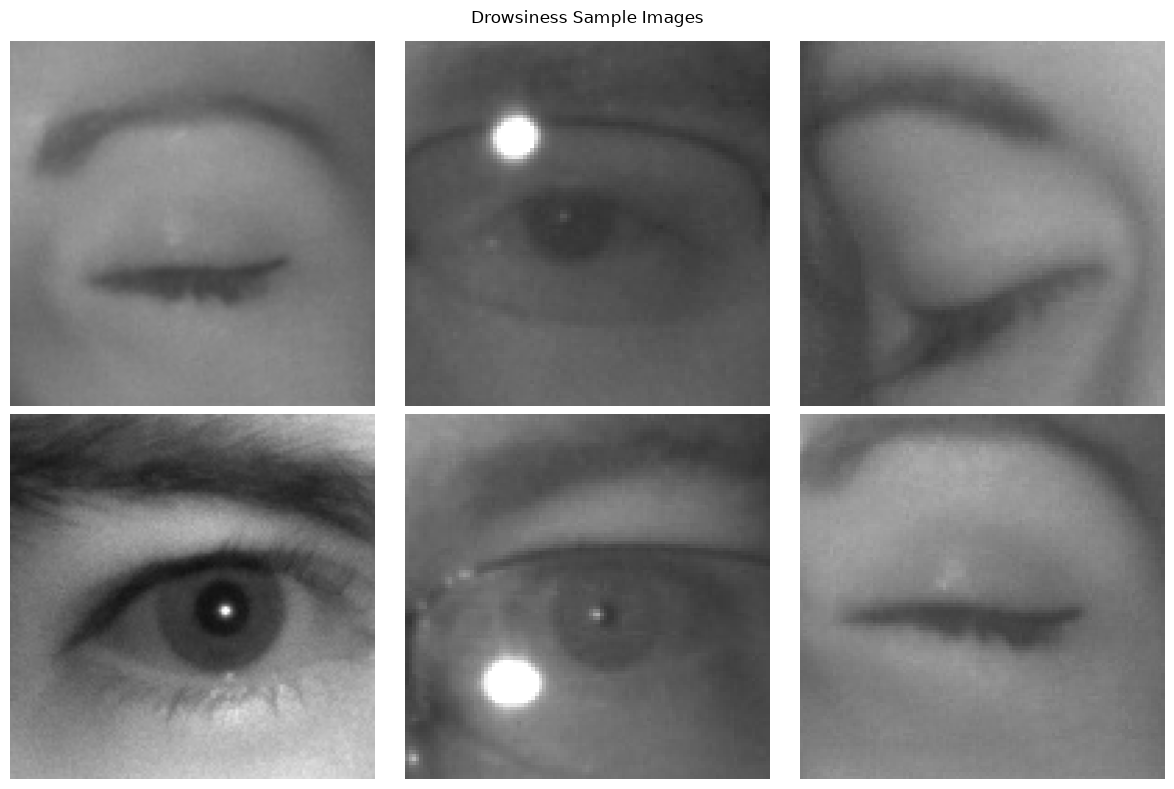

In [ ]:
show_dataset_samples("Drowsiness")

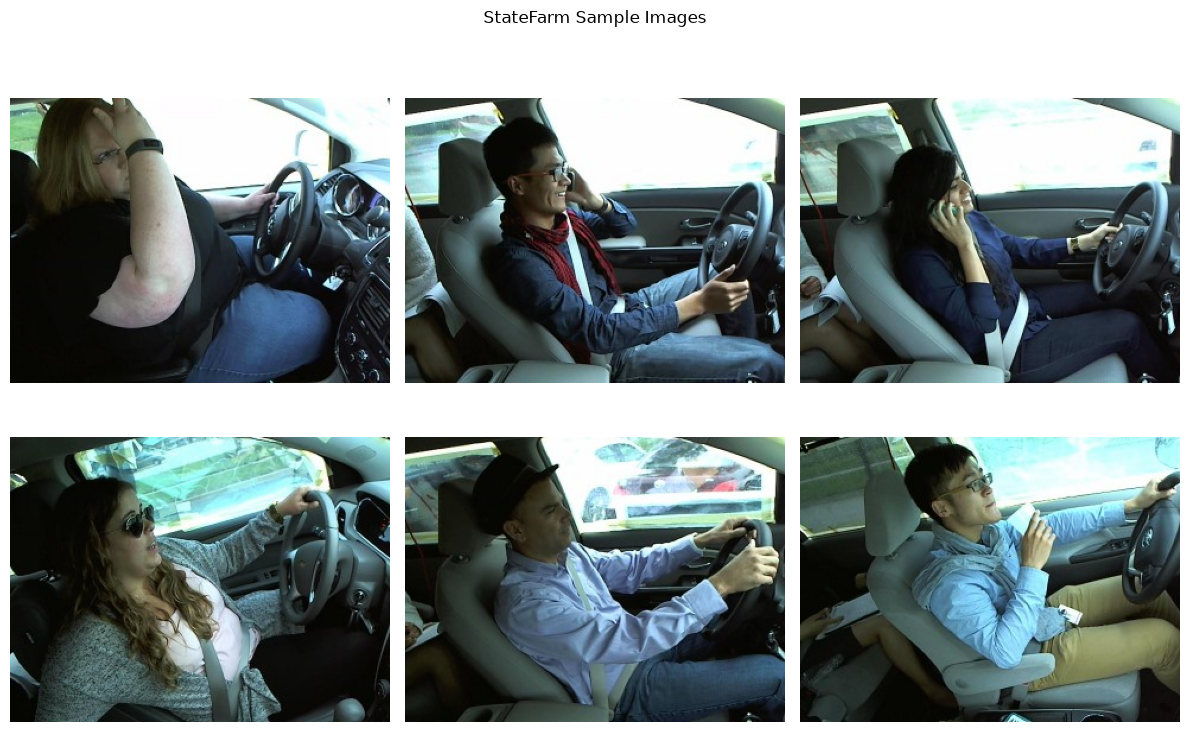

In [ ]:
show_dataset_samples("StateFarm")

- Observation:The three datasets exhibit distinct visual characteristics. ADMS focuses on object-level annotations related to driver safety, the Drowsiness dataset captures eye-state variations, while State Farm emphasizes driver activities and distractions.

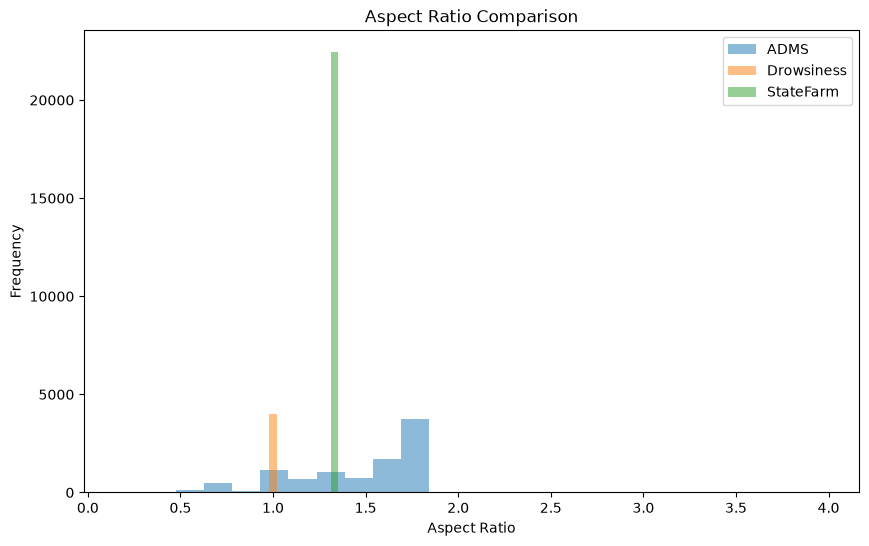

In [ ]:
datasets = metadata["dataset"].unique()
plt.figure(figsize=(10,6))
for dataset in datasets:
    subset = metadata[
        metadata["dataset"] == dataset
    ]
    plt.hist(
        subset["aspect_ratio"],
        bins=25,
        alpha=0.5,
        label=dataset
    )
plt.legend()
plt.title("Aspect Ratio Comparison")
plt.xlabel("Aspect Ratio")
plt.ylabel("Frequency")
plt.savefig(
    FIGURE_DIR/"aspect_ratio_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

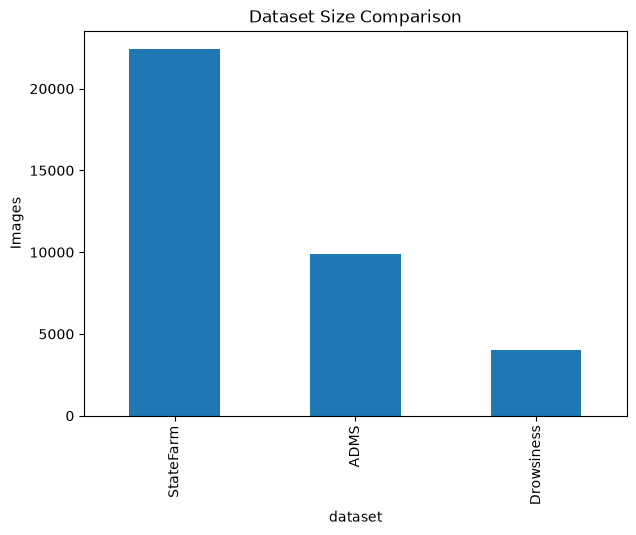

In [ ]:
dataset_counts = metadata["dataset"].value_counts()
plt.figure(figsize=(7,5))
dataset_counts.plot(kind="bar")
plt.ylabel("Images")
plt.title("Dataset Size Comparison")
plt.savefig(
    FIGURE_DIR/"dataset_size.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

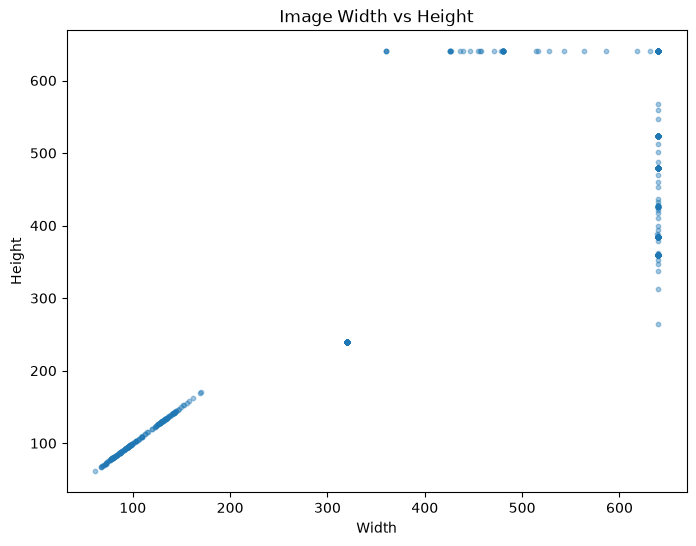

In [ ]:
sample_plot = metadata.sample(
    1500,
    random_state=42
)
plt.figure(figsize=(8,6))
plt.scatter(
    sample_plot["width"],
    sample_plot["height"],
    alpha=0.4,
    s=10
)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Width vs Height")
plt.savefig(
    FIGURE_DIR/"width_height_scatter.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

,brightness,contrast,blur_score
dataset,,,
ADMS,73.666321,54.395685,1148.845873
Drowsiness,94.446571,25.007999,71.846053
StateFarm,91.606483,79.774176,1916.173260


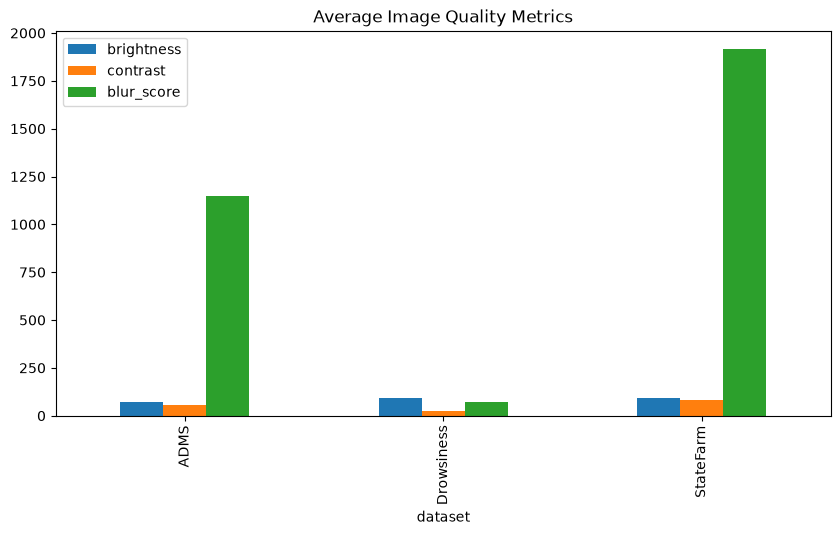

In [ ]:
quality = eda_sample.groupby("dataset")[
    [
        "brightness",
        "contrast",
        "blur_score"
    ]
].mean()
display(quality)
quality.plot(
    kind="bar",
    figsize=(10,5)
)
plt.title("Average Image Quality Metrics")
plt.savefig(
    FIGURE_DIR/"quality_by_dataset.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Notebook 3 Summary

### Key Findings

1. The integrated dataset contains 36,307 images collected from three public Driver Monitoring datasets.

2. Metadata analysis revealed differences in image resolution, aspect ratio, and image formats across datasets.

3. Image quality metrics demonstrated variability in brightness, contrast, and blur, supporting the inclusion of these attributes during feature engineering.

4. Dataset heterogeneity indicates that normalization and feature standardization will be necessary prior to model development.

### Transition to Notebook 4

The insights generated in this notebook will guide feature engineering, where image quality metrics, metadata, and dataset-specific characteristics will be transformed into machine learning features for baseline model development.